<a href="https://colab.research.google.com/github/Mangesh0309/Neural-Networks/blob/main/CNN_from_scratch_using_PyTorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training CNN from scratch using PyTorch with MNIST

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


1. Load and preprocess MNIST dataset


In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),    # Convert to(0,1)
    transforms.Normalize((0.1307,), (0.3081,))    # Normalizes with MNIST mean & standard deviation
])

train_dataset = datasets.MNIST(root='./data', train = True, download = True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train = False, download = True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)


2. Visualize some images

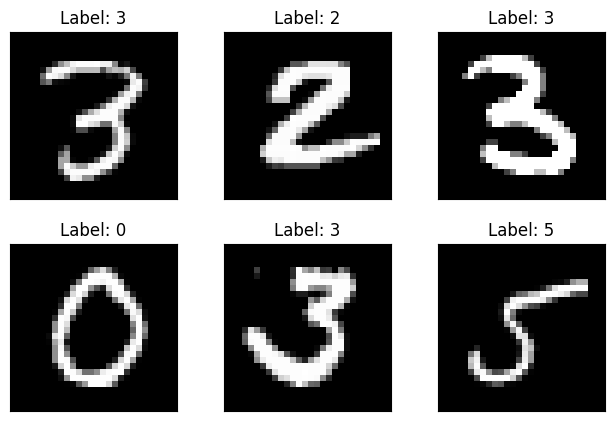

In [5]:
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig = plt.figure()
for i in range(6):
  plt.subplot(2, 3, i+1)
  plt.tight_layout()
  plt.imshow(example_data[i][0], cmap = 'gray', interpolation = 'none')
  plt.title("Label: {}".format(example_targets[i]))
  plt.xticks([])
  plt.yticks([])
plt.show()

3. Define CNN architecture

In [10]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
    self.dropout1 = nn.Dropout2d(0.25)
    self.dropout2 = nn.Dropout(0.5)
    self.fc1 = nn.Linear(9216, 128)
    self.fc2 = nn.Linear(128,10)

  def forward(self, x):
    x = F.relu(self.conv1(x))   # [batch, 32, 26, 26]
    x = F.relu(self.conv2(x))   # [batch, 64, 24, 24]
    x = F.max_pool2d(x, 2)      # [batch, 64, 12, 12]
    x = self.dropout1(x)
    x = torch.flatten(x, 1)     # Flatten all but batch
    x = F.relu(self.fc1(x))
    x = self.dropout2(x)
    x = self.fc2(x)
    return F.log_softmax(x, dim=1)

In [8]:
# Model Summary
!pip install torchsummary


4. Instantiate Model, define optimizer and loss

In [11]:
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
summary(model, (1, 28, 28))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 26, 26]             320
            Conv2d-2           [-1, 64, 24, 24]          18,496
         Dropout2d-3           [-1, 64, 12, 12]               0
            Linear-4                  [-1, 128]       1,179,776
           Dropout-5                  [-1, 128]               0
            Linear-6                   [-1, 10]           1,290
Total params: 1,199,882
Trainable params: 1,199,882
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.52
Params size (MB): 4.58
Estimated Total Size (MB): 5.10
----------------------------------------------------------------


5. Training Loop

In [12]:
def train(model, device, train_loader, optimizer, epoch):
  model.train()
  for batch_idx, (data, target) in enumerate(train_loader):
    data, target = data.to(device), target.to(device)

    optimizer.zero_grad()
    output = model(data)
    loss = F.nll_loss(output, target)
    loss.backward()
    optimizer.step()

    if batch_idx % 100 == 0 :
      print(f"Train Epoch : {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}]     Loss : {loss.item():.6f}")


6. Testing loop

In [13]:
def test (model, device, test_loader):
  model.eval()
  test_loss = 0
  correct = 0

  with torch.no_grad():
    for data, target in test_loader:
      data, target = data.to(device), target.to(device)

      output = model(data)
      test_loss += F.nll_loss(output, target, reduction='sum').item()
      pred = output.argmax(dim=1)
      correct += pred.eq(target).sum().item()

      test_loss /= len(test_loader.dataset)
      accuracy = 100. *correct / len(test_loader.dataset)

      print(f"\nTest set : Average Loss : {test_loss:.4f}, Accuracy : {correct}/{len(test_loader.dataset)} ({accuracy:.2f}% )\n" )

7. Run Training and Testing

In [14]:
for epoch in range(1, 6):
  train(model, device,  train_loader, optimizer, epoch)
  test(model, device, test_loader)


Train Epoch : 1 [0/60000]     Loss : 2.310281
Train Epoch : 1 [6400/60000]     Loss : 0.315434
Train Epoch : 1 [12800/60000]     Loss : 0.231784
Train Epoch : 1 [19200/60000]     Loss : 0.195510
Train Epoch : 1 [25600/60000]     Loss : 0.313668
Train Epoch : 1 [32000/60000]     Loss : 0.137786
Train Epoch : 1 [38400/60000]     Loss : 0.115234
Train Epoch : 1 [44800/60000]     Loss : 0.094991
Train Epoch : 1 [51200/60000]     Loss : 0.110512
Train Epoch : 1 [57600/60000]     Loss : 0.162540

Test set : Average Loss : 0.0041, Accuracy : 987/10000 (9.87% )


Test set : Average Loss : 0.0073, Accuracy : 1961/10000 (19.61% )


Test set : Average Loss : 0.0070, Accuracy : 2940/10000 (29.40% )


Test set : Average Loss : 0.0067, Accuracy : 3917/10000 (39.17% )


Test set : Average Loss : 0.0061, Accuracy : 4890/10000 (48.90% )


Test set : Average Loss : 0.0021, Accuracy : 5880/10000 (58.80% )


Test set : Average Loss : 0.0029, Accuracy : 6873/10000 (68.73% )


Test set : Average Loss : 0.00

8. Save the trained model

In [15]:
model_path = "mnist_cnn.pth"
torch.save(model.state_dict(), model_path)
print(f"Model save to {model_path}")


Model save to mnist_cnn.pth


9. Load the saved Model

In [16]:
loaded_model = CNN().to(device)
loaded_model.load_state_dict(torch.load(model_path))
loaded_model.eval()
print("Model Loaded Successfully")


Model Loaded Successfully


10. Make Prediction with loaded model

In [17]:
def predict(model, device, data_loader, num_samples=6):
  model.eval()
  data_iter = iter(data_loader)
  images, labels = next(data_iter)
  images, labels = images.to(device), labels.to(device)
  output = model(images)
  preds = output.argmax(dim=1)

  # Visualize Predictions
  fig = plt.figure()
  for i in range (num_samples):
    plt.subplot(2, 3, i+1)
    plt.tight_layout()
    plt.imshow(images[i][0].cpu(), cmap = 'gray', interpolation = 'none')
    plt.title(f"Pred : {preds[i].item()}, Label : {labels[i].item()}")
    plt.xticks([])
    plt.yticks([])
  plt.show()


11. Run predictions


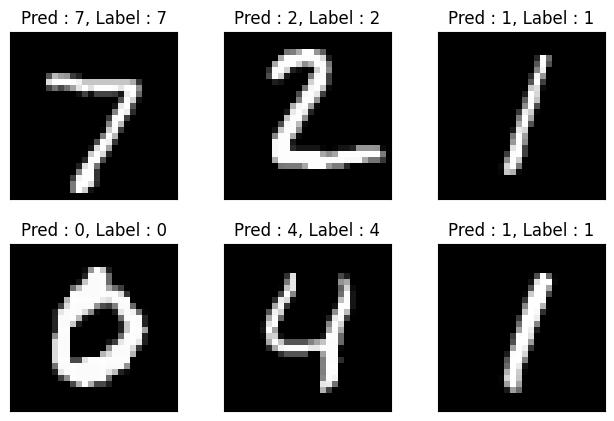

In [18]:
predict(loaded_model, device, test_loader)